In [1]:
%load_ext autoreload
%autoreload 2

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from cifar import constants, load_data
from omegaconf import OmegaConf
from typing import cast
from base import config

In [33]:
config_path = "cifar/experiment.yaml"
base_config = OmegaConf.structured(config.ExperimentConfig)
yaml_config = OmegaConf.load(config_path)

exp_config = cast(
    config.ExperimentConfig, OmegaConf.merge(base_config, yaml_config)
)

In [34]:
train = load_data.unpickle("/Volumes/satechi/ml_projects/cifar/data/train")

/Users/peterwen/projects/learn_cv/cifar/load_data.py:39: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict_data = pk.load(f, encoding="latin1")


In [62]:
img = train["data"].reshape(-1, 3, 32, 32)[0]

In [63]:
img.shape

(3, 32, 32)

In [64]:
size = 5
fill_value = 0
_, height, width = img.shape
x_center = np.random.choice(np.arange(width)).item()
y_center= np.random.choice(np.arange(height)).item()

In [65]:
x_start = x_center - size // 2
x_end = x_start + size

y_start = y_center - size // 2
y_end = y_start + size

In [69]:
img[:, x_start: x_end, y_start: y_end] = fill_value

In [ ]:
class Cutup:
    def __init__(self, size: int, fill_value: int = 0, count: int = 1):
        self.size = size
        self.fill_value = fill_value
        self.count = count

    def __call__(self, img):
        _, height, width = img.shape

        for _ in range(self.count):
            x_center = np.random.choice(np.arange(width)).item()
            y_center= np.random.choice(np.arange(height)).item()
            x_start = x_center -  size // 2
            x_end = x_start + size

            y_start = y_center - size // 2
            y_end = y_start + size

            img[:, x_start: x_end, y_start: y_end] = fill_value

        return img

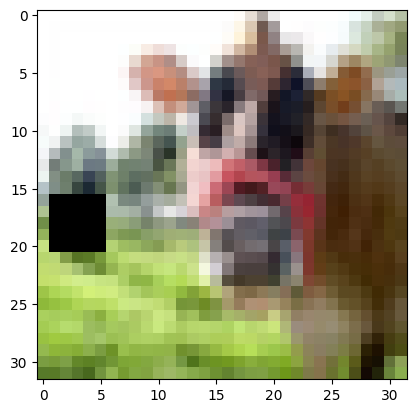

In [70]:
plt.imshow(img.transpose(1, 2, 0))